# **METODY SYSTEMOWE I DECYZYJNE LISTA 1**

## 1. Przygotowanie środowiska

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error


plt.rcParams.update({
    'figure.facecolor':  '#FAFAFA',
    'axes.facecolor':    '#FFFFFF',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.labelsize':    12,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'font.family':       'DejaVu Sans',
    'figure.dpi':        120,
})

PALETTE   = ['#185FA5', '#BA7517', '#3B6D11', '#534AB7', '#A32D2D', '#0F6E56']
BLUE      = '#185FA5'
GOLD      = '#BA7517'
GREEN     = '#3B6D11'
RED       = '#A32D2D'
DISORDER_COLORS = {'Healthy': '#3B6D11', 'Mild': '#BA7517', 'Moderate': '#E8893A', 'Severe': '#A32D2D'}

### 2. Wczytanie i podzielenie zbioru danych

In [11]:
file_path = "../resources/sleep_health_dataset.csv"

_df = pd.read_csv(file_path, )

print(f"Size of the whole dataset: {_df.shape[0]} columns x {_df.shape[1]} rows")

train_df, test_df = train_test_split(_df, test_size=0.2, random_state=42, stratify=_df['felt_rested'])

print(f"Size of the train set: {train_df.shape[0]} columns x {train_df.shape[1]} rows")

train_df.head(5)

Size of the whole dataset: 100000 columns x 32 rows
Size of the train set: 80000 columns x 32 rows


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
31687,31688,40,Female,Manager,25.3,Germany,6.53,6.8,21.4,27.6,...,76,1,0,25.9,1.29,Summer,Weekend,100.0,Healthy,1
97392,97393,21,Female,Retired,23.1,UK,8.92,7.9,22.1,22.7,...,71,1,0,21.0,1.44,Autumn,Weekday,97.5,Healthy,1
28709,28710,42,Male,Software Engineer,30.9,India,5.76,3.5,19.0,22.9,...,66,1,0,20.6,0.46,Summer,Weekday,69.5,Mild,0
33880,33881,36,Male,Retired,20.5,Japan,7.68,7.4,15.1,14.8,...,71,0,0,18.7,1.89,Winter,Weekday,69.0,Healthy,0
97236,97237,40,Female,Lawyer,27.6,USA,5.98,1.8,22.3,21.9,...,77,1,1,17.3,1.91,Winter,Weekday,32.4,Severe,0


### 3. Eksploracyjna analiza wybranych danych ciągłych

In [12]:
# Testing and checking for invalid data
num_data = train_df.select_dtypes(include=np.number).columns.drop("person_id").tolist()
cat_data = train_df.select_dtypes(exclude=np.number).columns.tolist()

print(f"Liczba danych ciągłych: {len(num_data)} \nliczba dancyh kategorialnych: {len(cat_data)}")

train_df.info()
train_df.describe().round(2)

Liczba danych ciągłych: 23 
liczba dancyh kategorialnych: 8
<class 'pandas.DataFrame'>
Index: 80000 entries, 31687 to 13273
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    80000 non-null  int64  
 1   age                          80000 non-null  int64  
 2   gender                       80000 non-null  str    
 3   occupation                   80000 non-null  str    
 4   bmi                          80000 non-null  float64
 5   country                      80000 non-null  str    
 6   sleep_duration_hrs           80000 non-null  float64
 7   sleep_quality_score          80000 non-null  float64
 8   rem_percentage               80000 non-null  float64
 9   deep_sleep_percentage        80000 non-null  float64
 10  sleep_latency_mins           80000 non-null  int64  
 11  wake_episodes_per_night      80000 non-null  int64  
 12  caffeine_mg_before_bed    

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,...,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00
mean,50080.90,34.71,26.30,6.42,4.87,20.24,20.26,19.84,3.35,38.78,...,14.93,5.73,7.14,66.58,0.56,0.08,20.54,1.20,59.24,0.39
std,28871.61,11.03,4.48,1.28,1.51,3.41,4.25,7.59,1.92,69.26,...,21.40,1.62,3.48,7.22,0.50,0.28,2.90,0.79,22.25,0.49
min,1.00,18.00,16.00,3.00,1.00,10.00,5.00,1.00,0.00,0.00,...,0.00,1.00,0.00,45.00,0.00,0.00,15.00,-1.00,0.00,0.00
25%,25062.75,26.00,23.20,5.53,3.80,18.00,17.40,14.00,2.00,0.00,...,0.00,4.80,4.70,62.00,0.00,0.00,18.50,0.67,44.20,0.00
50%,50147.50,33.00,26.30,6.36,4.90,20.30,20.30,19.00,3.00,0.00,...,0.00,5.80,7.40,67.00,1.00,0.00,20.50,1.20,60.40,0.00
75%,75043.25,42.00,29.30,7.27,6.00,22.60,23.20,25.00,5.00,80.00,...,30.00,6.80,9.70,71.00,1.00,0.00,22.50,1.74,75.80,1.00
max,100000.00,69.00,45.00,10.50,10.00,30.00,30.00,58.00,8.00,400.00,...,116.00,10.00,18.00,99.00,1.00,1.00,28.00,3.00,100.00,1.00


### 4. Najciekawsze cechy i zależności

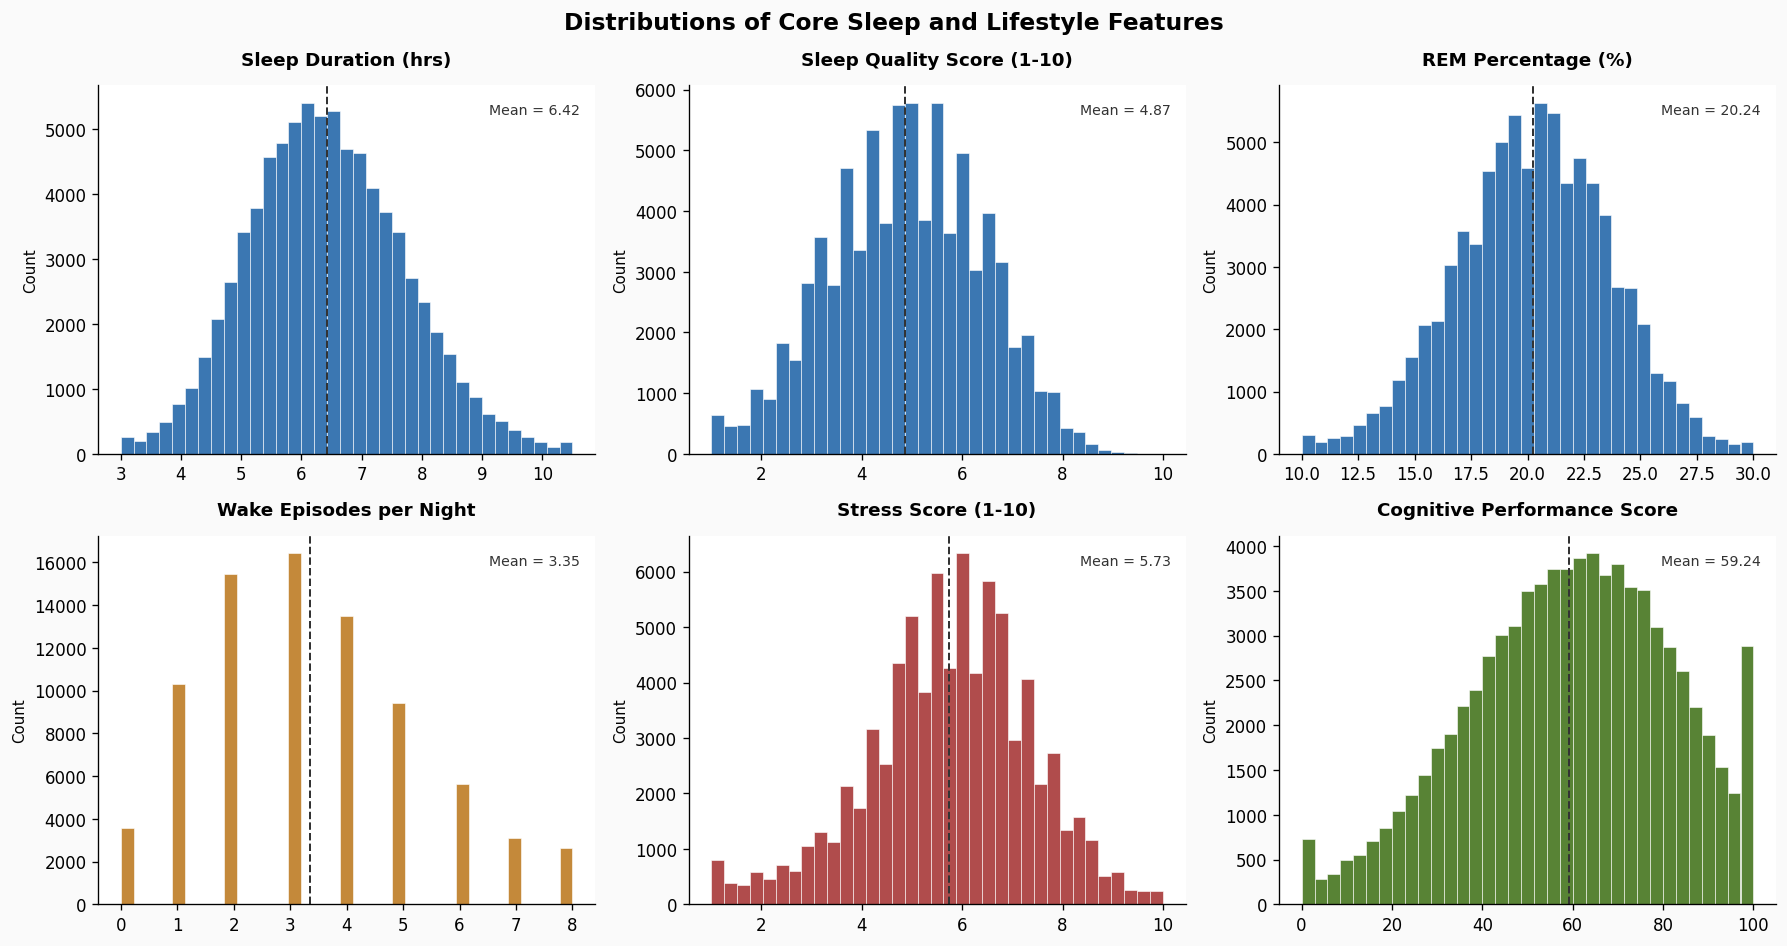

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distributions of Core Sleep and Lifestyle Features', fontsize=14, fontweight='bold')

features = [
    ('sleep_duration_hrs',         'Sleep Duration (hrs)',        BLUE),
    ('sleep_quality_score',        'Sleep Quality Score (1-10)',  BLUE),
    ('rem_percentage',             'REM Percentage (%)',          BLUE),
    ('wake_episodes_per_night',    'Wake Episodes per Night',     GOLD),
    ('stress_score',               'Stress Score (1-10)',         RED),
    ('cognitive_performance_score','Cognitive Performance Score', GREEN),
]


for ax, (col, label, color) in zip(axes.flat, features):
    ax.hist(train_df[col], bins=35, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(train_df[col].mean(), color='#333333', linestyle='--', linewidth=1.2)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=9)
    mean_txt = f'Mean = {train_df[col].mean():.2f}'
    ax.text(0.97, 0.95, mean_txt, transform=ax.transAxes,
            ha='right', va='top', fontsize=8.5, color='#333333')

plt.tight_layout()

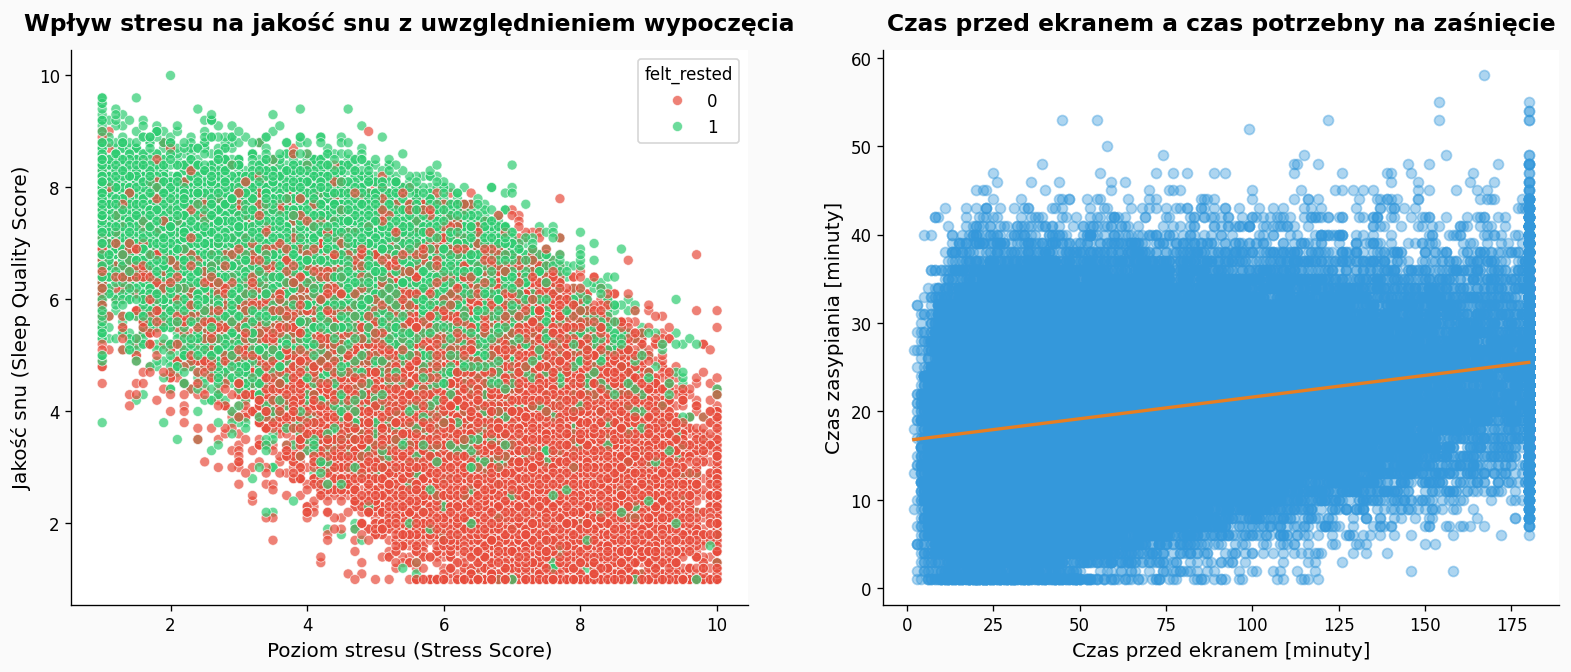

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# wykres jakości snu względem wypoczęcia
sns.scatterplot(
    data=train_df,
    x='stress_score',
    y='sleep_quality_score',
    hue='felt_rested',
    palette={0: '#e74c3c', 1: '#2ecc71'},
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Wpływ stresu na jakość snu z uwzględnieniem wypoczęcia', fontsize=14)
axes[0].set_xlabel('Poziom stresu (Stress Score)', fontsize=12)
axes[0].set_ylabel('Jakość snu (Sleep Quality Score)', fontsize=12)

# wykres zależności sleep latency od screen-time'u
sns.regplot(
    data=train_df,
    x='screen_time_before_bed_mins',
    y='sleep_latency_mins',
    scatter_kws={'alpha': 0.4, 'color': '#3498db'},
    line_kws={'color': '#e67e22', 'linewidth': 2},
    ax=axes[1]
)
axes[1].set_title('Czas przed ekranem a czas potrzebny na zaśnięcie', fontsize=14)
axes[1].set_xlabel('Czas przed ekranem [minuty]', fontsize=12)
axes[1].set_ylabel('Czas zasypiania [minuty]', fontsize=12)

plt.show()

### 5. Ekspolaracyjna analiza danych kategorialnych

In [15]:
cat_cols = ['gender', 'occupation', 'country',
            'chronotype', 'mental_health_condition', 'season',
            'day_type', 'sleep_disorder_risk', 'exercise_day',
            'sleep_aid_used', 'shift_work', 'felt_rested']

print("Podsumowanie cech kategorialnych w zbiorze treningowym:\n")

for col in cat_cols:
    unique_count = train_df[col].nunique()
    print(f"Cecha: **{col}** | Unikalnych wartości: {unique_count}")

    value_counts = train_df[col].value_counts()
    proportions = train_df[col].value_counts(normalize=True) * 100

    summary_df = pd.DataFrame({
        'Liczebność': value_counts,
        'Procent (%)': proportions.round(2)
    })
    print(summary_df.head())
    print("-" * 30)

Podsumowanie cech kategorialnych w zbiorze treningowym:

Cecha: **gender** | Unikalnych wartości: 3
        Liczebność  Procent (%)
gender                         
Female       40118        50.15
Male         38298        47.87
Other         1584         1.98
------------------------------
Cecha: **occupation** | Unikalnych wartości: 12
                   Liczebność  Procent (%)
occupation                                
Student                 11810        14.76
Software Engineer        9680        12.10
Nurse                    8082        10.10
Teacher                  6497         8.12
Manager                  6403         8.00
------------------------------
Cecha: **country** | Unikalnych wartości: 15
         Liczebność  Procent (%)
country                         
USA           15995        19.99
India         14374        17.97
Japan          6468         8.09
UK             6364         7.95
Brazil         5663         7.08
------------------------------
Cecha: **chronotype** 

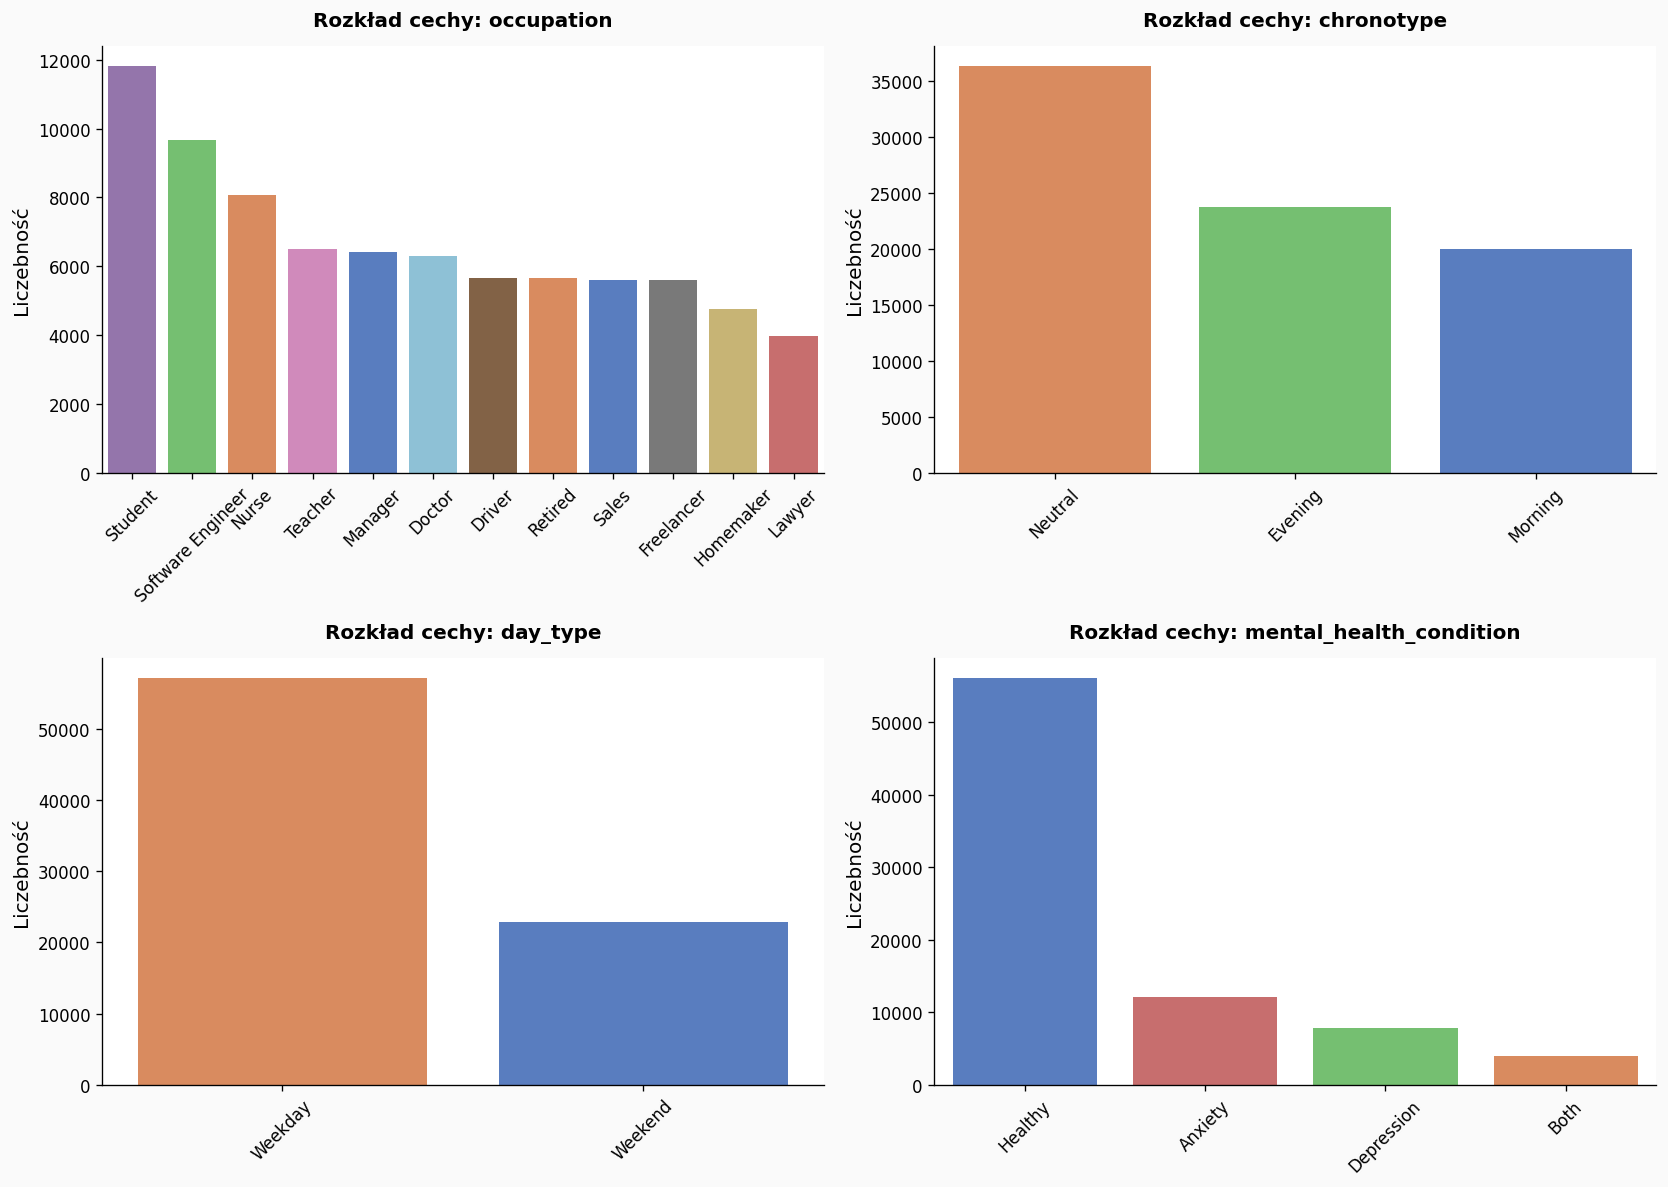

In [16]:
features_to_plot = ['occupation', 'chronotype', 'day_type', 'mental_health_condition']

features_to_plot = [feat for feat in features_to_plot if feat in cat_cols]

if features_to_plot:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for i, feature in enumerate(features_to_plot):
        row = i // 2
        col = i % 2

        sns.countplot(
            data=train_df,
            x=feature,
            hue=feature,
            palette='muted',
            legend=False,
            ax=axes[row, col],
            order=train_df[feature].value_counts().index
        )
        axes[row, col].set_title(f'Rozkład cechy: {feature}', fontsize=12)
        axes[row, col].tick_params(axis='x', rotation=45)
        axes[row, col].set_ylabel('Liczebność')
        axes[row, col].set_xlabel('')

    plt.tight_layout()
    plt.show()

### 6. Prosty system przewidywania cechy _felt_rested_

In [17]:
# grid search
def calculateThreshold():
    feature = 'sleep_quality_score'
    best_threshold = 0
    best_train_acc = 0

    # generating 100 possible thresholds
    thresholds_to_test = np.linspace(train_df[feature].min(), train_df[feature].max(), 100)

    for thresh in thresholds_to_test:
        train_predictions = (train_df[feature] > thresh).astype(int)

        # calculate accuracy for current threshold
        acc = accuracy_score(train_df['felt_rested'], train_predictions)

        # save the best score
        if acc > best_train_acc:
            best_train_acc = acc
            best_threshold = thresh

    return best_threshold, best_train_acc

# basic prediction function
def predict(sleep_quality: float, threshold: float) -> int: # 0,1
    if sleep_quality > best_threshold:
        return 1
    else:
        return 0

# ---------- Testing -------------
best_threshold, best_train_acc = calculateThreshold()
feature = 'sleep_quality_score'

print(f"--- Faza Treningu ---")
print(f"Znaleziony optymalny próg jakości snu: {best_threshold:.2f}")
print(f"Accuracy na zbiorze treningowym: {best_train_acc:.2%}\n")

# get real values
y_true_test = test_df['felt_rested']

# predict values using predict()
y_pred_test = test_df[feature].apply(predict, args=(best_threshold, ))

# calculate accuracy
test_accuracy = accuracy_score(y_true_test, y_pred_test)

print(f"--- Faza Testów (Ewaluacja) ---")
print(f"Accuracy na zbiorze testowym: {test_accuracy:.2%}")

--- Faza Treningu ---
Znaleziony optymalny próg jakości snu: 5.45
Accuracy na zbiorze treningowym: 71.79%

--- Faza Testów (Ewaluacja) ---
Accuracy na zbiorze testowym: 71.64%


### 7. Złożony system przewidywania cechy _felt_rested_

In [18]:
def predict_complex(row, quality_threshold: float) -> int:
    quality = row['sleep_quality_score']
    duration = row['sleep_duration_hrs']
    stress = row['stress_score']
    latency = row['sleep_latency_mins']
    wakes = row['wake_episodes_per_night']

    # is sleep quatily better than threshold?
    if quality > quality_threshold:
        # if sleep duration is not long enough then False
        if duration < 5.5:
            return 0
        else:
            # if stress level is high then False
            if stress > 7.0:
                return 0
            else:
                # if latency is too long then False
                if latency > 40:
                    return 0
                else:
                    return 1
    else:
        # if quality is bad, but slept long enough then True
        if duration >= 8.0:
            return 1
        else:
            return 0


# ---------- Testing -------------
sleep_q_threshold = calculateThreshold()

# get real values
y_true_test = test_df['felt_rested']

# predict values using predict_complex()
y_pred_test_complex = test_df.apply(predict_complex, axis=1, args=(sleep_q_threshold, ))

complex_test_accuracy = accuracy_score(y_true_test, y_pred_test_complex)

print(f"--- Faza Testów Złożonego Systemu ---")
print(f"Accuracy na zbiorze TESTOWYM: {complex_test_accuracy:.2%}")

TypeError: '>' not supported between instances of 'float' and 'tuple'

### 8. Problem regresji dla cechy _cognitive_performance_score_

In [ ]:
# Grupa 1: Dobra jakość snu i Niski stres
mask1 = (train_df['sleep_quality_score'] > 6.0) & (train_df['stress_score'] < 5.0)
mean_group1 = train_df[mask1]['cognitive_performance_score'].mean()

# Grupa 2: Dobra jakość snu, ale Wysoki stres
mask2 = (train_df['sleep_quality_score'] > 6.0) & (train_df['stress_score'] >= 5.0)
mean_group2 = train_df[mask2]['cognitive_performance_score'].mean()

# Grupa 3: Słabsza jakość snu, ale Długi sen (nadrabianie)
mask3 = (train_df['sleep_quality_score'] <= 6.0) & (train_df['sleep_duration_hrs'] >= 6.5)
mean_group3 = train_df[mask3]['cognitive_performance_score'].mean()

# Grupa 4: Słaba jakość snu i Krótki sen (najgorszy scenariusz)
mask4 = (train_df['sleep_quality_score'] <= 6.0) & (train_df['sleep_duration_hrs'] < 6.5)
mean_group4 = train_df[mask4]['cognitive_performance_score'].mean()

print("--- Wyliczone średnie sprawności poznawczej (zbiór treningowy) ---")
print(f"Grupa 1 (Dobry sen, mało stresu): {mean_group1:.2f}")
print(f"Grupa 2 (Dobry sen, duży stres):  {mean_group2:.2f}")
print(f"Grupa 3 (Gorszy sen, ale długi):  {mean_group3:.2f}")
print(f"Grupa 4 (Zły i krótki sen):       {mean_group4:.2f}\n")


# assign element to particular group
def predict_regression(sleep_quality: float, stress: float, sleep_duration: float) -> float:
    if sleep_quality > 6.0:
        if stress < 5.0:
            return mean_group1
        else:
            return mean_group2
    else:
        if sleep_duration >= 6.5:
            return mean_group3
        else:
            return mean_group4


# get real values
y_true = test_df['cognitive_performance_score']

# predicting using predict_regression()
y_pred = test_df.apply(lambda row: predict_regression(
    row['sleep_quality_score'],
    row['stress_score'],
    row['sleep_duration_hrs']
), axis=1)

# calculate results
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)


print("--- Wyniki na zbiorze testowym ---")
print(f"MSE (Mean Squared Error):  {mse:.2f}")
print(f"MAE (Mean Absolute Error): {mae:.2f}")

### 9. Porównanie wartości rzeczywistych z predykcją

In [ ]:
# predict for train set
y_true_train = train_df['cognitive_performance_score']
y_pred_train = train_df.apply(lambda row: predict_regression(
    row['sleep_quality_score'],
    row['stress_score'],
    row['sleep_duration_hrs']
), axis=1)

# predict for test set
y_true_test = test_df['cognitive_performance_score']
y_pred_test = test_df.apply(lambda row: predict_regression(
    row['sleep_quality_score'],
    row['stress_score'],
    row['sleep_duration_hrs']
), axis=1)


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# train set plot
sns.scatterplot(x=y_true_train, y=y_pred_train, ax=axes[0], alpha=0.4, color='#3498db')
axes[0].plot([y_true_train.min(), y_true_train.max()],
             [y_true_train.min(), y_true_train.max()],
             'r--', lw=2, label='Idealna predykcja')

axes[0].set_title('Zbiór Treningowy: Rzeczywistość vs Predykcja', fontsize=14)
axes[0].set_xlabel('Rzeczywista sprawność poznawcza (True Values)', fontsize=12)
axes[0].set_ylabel('Przewidziana sprawność poznawcza (Predictions)', fontsize=12)
axes[0].legend()

# test set plot
sns.scatterplot(x=y_true_test, y=y_pred_test, ax=axes[1], alpha=0.4, color='#2ecc71')
axes[1].plot([y_true_test.min(), y_true_test.max()],
             [y_true_test.min(), y_true_test.max()],
             'r--', lw=2, label='Idealna predykcja')

axes[1].set_title('Zbiór Testowy: Rzeczywistość vs Predykcja', fontsize=14)
axes[1].set_xlabel('Rzeczywista sprawność poznawcza (True Values)', fontsize=12)
axes[1].set_ylabel('Przewidziana sprawność poznawcza (Predictions)', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()